# 12 — ReSpeaker Array Characterization

**Goal**: establish quantitative expectations for the ReSpeaker XVF3800 4-mic circular
array before any hardware experiments.  This is a pure simulation notebook — no hardware
required.

Hardware: 4 microphones, equal 90° spacing, ~45 mm radius (90 mm aperture).

Key questions answered here:

1. What beamwidth and spatial aliasing frequency does this geometry produce?
2. How do D&S, MVDR, CLEAN-SC, and MUSIC perform with only 4 mics?
3. How many snapshots are needed for CSM convergence?
4. How does Phase 2 performance compare to the Phase 4 target (96-mic, 300 mm)?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C       = 343.0        # speed of sound (m/s)
RADIUS  = 0.045        # 90mm aperture / 2
N_MICS  = 4
SNR_DB  = 20.0
N_SNAP  = 256
colors  = {'D&S': 'steelblue', 'MVDR': 'darkorange',
           'CLEAN-SC': 'forestgreen', 'MUSIC': 'crimson'}


## 1 — Array Geometry

Four microphones at 0°, 90°, 180°, 270° on a circle of radius 45 mm.
Note: the actual mic positions will be read from the device via `AEC_MIC_ARRAY_GEO`
in nb13; this notebook uses the nominal geometry for simulation.


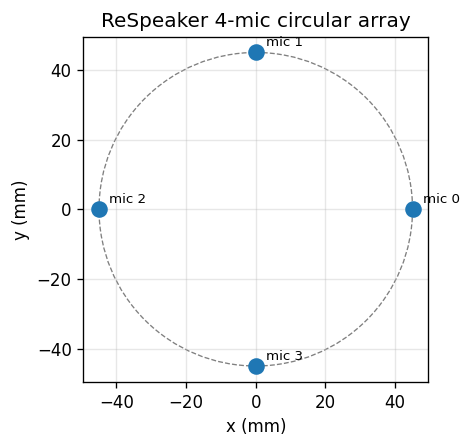

Radius:          45.0 mm
Adjacent chord:  63.6 mm
Spatial Nyquist: 2695 Hz  (effective ceiling ~2425 Hz)


In [2]:
angles_deg = np.array([0.0, 90.0, 180.0, 270.0])
x = RADIUS * np.cos(np.radians(angles_deg))   # (4,)
y = RADIUS * np.sin(np.radians(angles_deg))   # (4,)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x * 1000, y * 1000, s=80, zorder=5)
for i, (xi, yi) in enumerate(zip(x * 1000, y * 1000)):
    ax.annotate(f'mic {i}', (xi, yi), textcoords='offset points',
                xytext=(6, 4), fontsize=8)
circle = plt.Circle((0, 0), RADIUS * 1000, fill=False,
                     linestyle='--', color='gray', linewidth=0.8)
ax.add_patch(circle)
ax.set_aspect('equal')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('ReSpeaker 4-mic circular array')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('respeaker_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

# Key geometry metrics
d_adjacent = 2 * RADIUS * np.sin(np.radians(45))   # chord between adjacent mics
f_nyquist  = C / (2 * d_adjacent)
print(f'Radius:          {RADIUS*1000:.1f} mm')
print(f'Adjacent chord:  {d_adjacent*1000:.1f} mm')
print(f'Spatial Nyquist: {f_nyquist:.0f} Hz  (effective ceiling ~{0.9*f_nyquist:.0f} Hz)')


In [3]:
def sv(x, y, az_deg, freq):
    """Single far-field steering vector."""
    u = np.sin(np.radians(az_deg))
    return np.exp(1j * 2 * np.pi * freq / C * u * x) / np.sqrt(len(x))


def sm(x, y, az_grid, freq):
    """Steering matrix (N_mics, N_az)."""
    u = np.sin(np.radians(az_grid))
    return np.exp(1j * 2 * np.pi * freq / C * np.outer(x, u)) / np.sqrt(len(x))


def make_R(x, y, src_azimuths, freq, snr_db):
    """Theoretical CSM for one or more equal-power far-field sources."""
    N = len(x)
    noise_var = 1.0 / (10 ** (snr_db / 10))
    R = noise_var * np.eye(N, dtype=complex)
    for az in src_azimuths:
        h = sv(x, y, az, freq)
        R += np.outer(h, h.conj())
    return R


def sample_csm(R_true, n_snap, seed=None):
    """Cholesky sampling for finite-snapshot CSM."""
    rng = np.random.default_rng(seed)
    N   = R_true.shape[0]
    reg = 1e-10 * np.trace(R_true) / N
    L   = np.linalg.cholesky(R_true + reg * np.eye(N))
    R_s = np.zeros((N, N), dtype=complex)
    for _ in range(n_snap):
        z   = rng.standard_normal(N) + 1j * rng.standard_normal(N)
        y_s = L @ z / np.sqrt(2)
        R_s += np.outer(y_s, y_s.conj())
    return R_s / n_snap


def beamform_ds(x, y, R, freq, az_grid):
    H = sm(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N  = R.shape[0]
    Rl = R + diag_load * np.trace(R) / N * np.eye(N)
    Ri = inv(Rl)
    H  = sm(x, y, az_grid, freq)
    d  = np.real(np.sum(H.conj() * (Ri @ H), axis=0))
    return 1.0 / np.maximum(d, 1e-300)


def clean_sc(x, y, R, freq, az_grid, n_iter=40, loop_gain=0.5):
    """1-D CLEAN-SC (Sijtsma 2007)."""
    H      = sm(x, y, az_grid, freq)   # (N, N_az)
    R_w    = R.copy()
    clean  = np.zeros(len(az_grid))
    for _ in range(n_iter):
        P = np.real(np.sum(H.conj() * (R_w @ H), axis=0))
        k = np.argmax(P)
        g = R_w @ H[:, k]              # coherence vector
        R_w   -= loop_gain * np.outer(g, g.conj())
        clean[k] += loop_gain * np.real(g.conj() @ g)
    return clean


def beamform_music(x, y, R, freq, az_grid, n_sources=1):
    _, ev = np.linalg.eigh(R)
    En    = ev[:, :R.shape[0] - n_sources]
    Ep    = En @ En.conj().T
    H     = sm(x, y, az_grid, freq)
    d     = np.real(np.sum(H.conj() * (Ep @ H), axis=0))
    return 1.0 / np.maximum(d, 1e-300)


def db_norm(p):
    return 10 * np.log10(np.maximum(p / p.max(), 1e-10))


def measure_hpbw(az_grid, pattern):
    """Half-power (-3 dB) beamwidth in degrees."""
    half = pattern.max() / 2
    above = pattern >= half
    if not above.any():
        return float('nan')
    left  = az_grid[np.argmax(above)]
    right = az_grid[len(above) - 1 - np.argmax(above[::-1])]
    if right <= left:
        return float('nan')
    return right - left


az_grid = np.linspace(-90, 90, 1801)
print('Helpers defined.')


Helpers defined.


## 2 — PSF and HPBW vs Frequency

Delay-and-Sum point spread function for a boresight source at each frequency.
HPBW is measured as the −3 dB beamwidth.


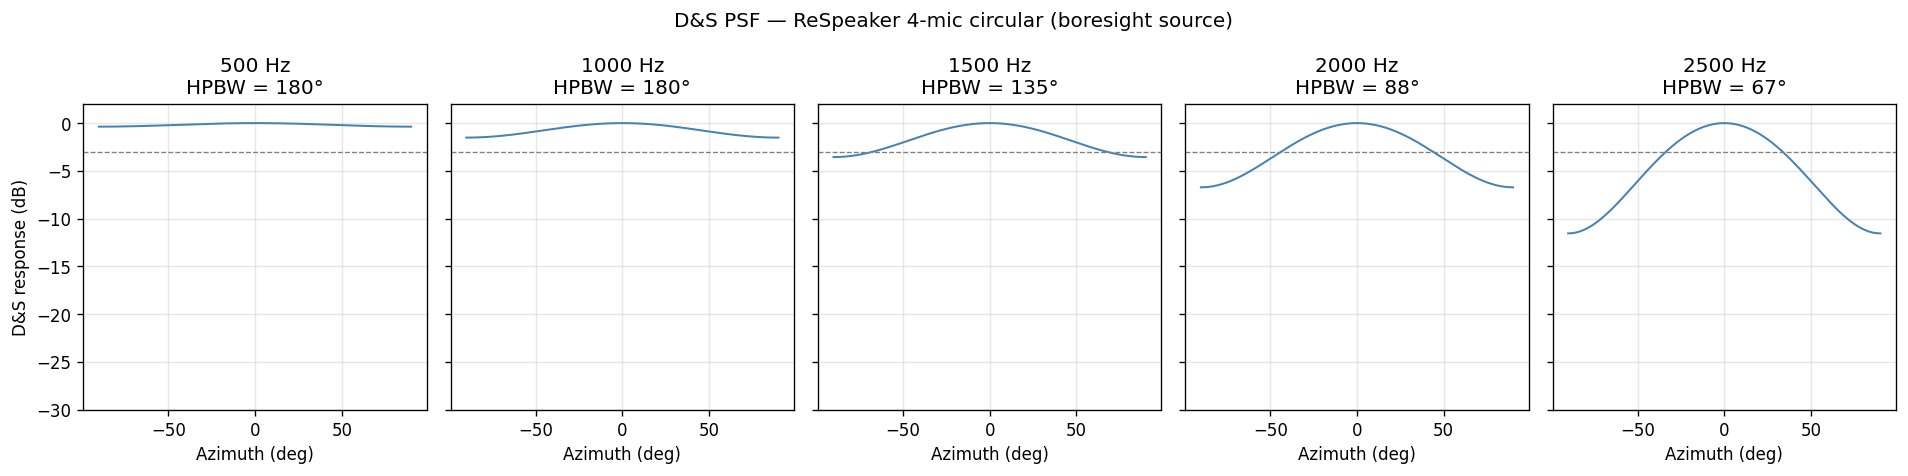

HPBW vs frequency:
    500 Hz  HPBW = 180°
   1000 Hz  HPBW = 180°
   1500 Hz  HPBW = 135°
   2000 Hz  HPBW = 88°
   2500 Hz  HPBW = 67°


In [4]:
FREQS    = [500, 1000, 1500, 2000, 2500]
hpbw_arr = []

fig, axes = plt.subplots(1, len(FREQS), figsize=(16, 4), sharey=True)

for ax, freq in zip(axes, FREQS):
    h0 = sv(x, y, 0.0, freq)
    R0 = np.outer(h0, h0.conj())          # noiseless, single source
    P  = beamform_ds(x, y, R0, freq, az_grid)
    P_db = db_norm(P)
    hpbw = measure_hpbw(az_grid, P)
    hpbw_arr.append(hpbw)
    ax.plot(az_grid, P_db, color='steelblue', linewidth=1.2)
    ax.axhline(-3, color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylim(-30, 2)
    ax.set_xlabel('Azimuth (deg)')
    ax.set_title(f'{freq} Hz\nHPBW = {hpbw:.0f}°' if not np.isnan(hpbw)
                 else f'{freq} Hz\nHPBW = omni')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('D&S response (dB)')
plt.suptitle('D&S PSF — ReSpeaker 4-mic circular (boresight source)')
plt.tight_layout()
plt.savefig('respeaker_psf.png', dpi=150, bbox_inches='tight')
plt.show()

print('HPBW vs frequency:')
for freq, hpbw in zip(FREQS, hpbw_arr):
    tag = f'{hpbw:.0f}°' if not np.isnan(hpbw) else '>180° (omni)'
    print(f'  {freq:5d} Hz  HPBW = {tag}')


## 3 — Spatial Aliasing

The regular 90° spacing creates a single strong grating lobe when the
frequency exceeds the spatial Nyquist.


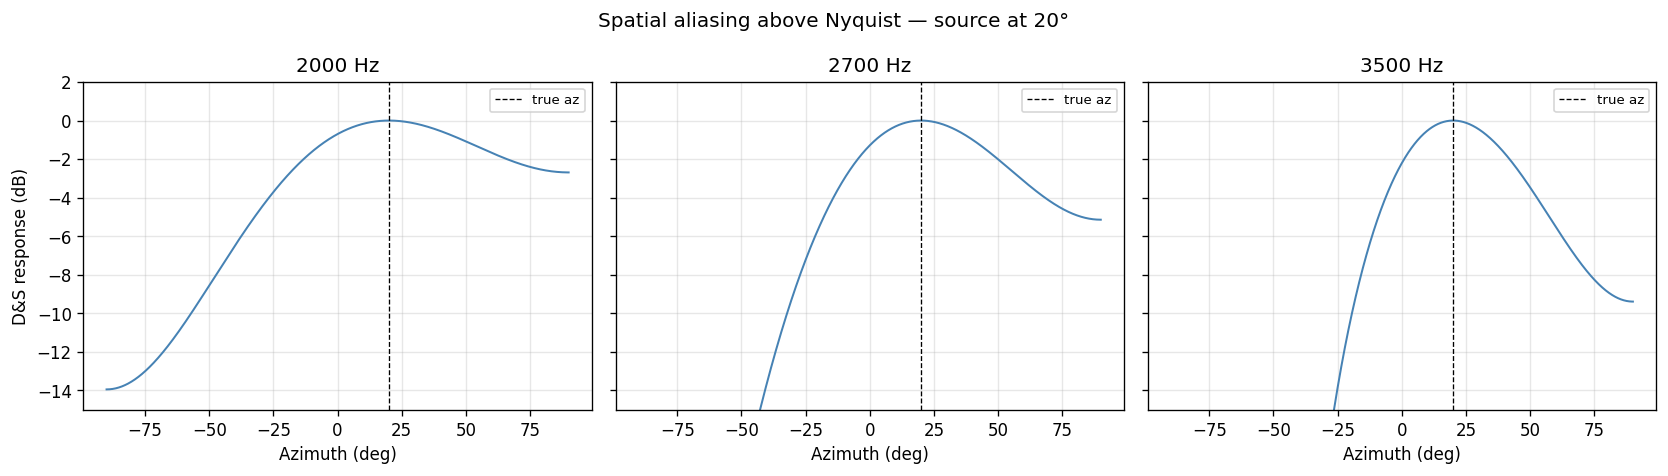

Spatial Nyquist: 2695 Hz
Above Nyquist: single grating lobe appears (regular spacing = periodic grating)
Underbrink array distributes alias energy across many weak irregular lobes instead.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, freq in zip(axes, [2000, 2700, 3500]):
    h0 = sv(x, y, 20.0, freq)
    R0 = np.outer(h0, h0.conj())
    P  = beamform_ds(x, y, R0, freq, az_grid)
    ax.plot(az_grid, db_norm(P), color='steelblue', linewidth=1.2)
    ax.axvline(20, color='k', linestyle='--', linewidth=0.8, label='true az')
    ax.set_ylim(-15, 2)
    ax.set_xlabel('Azimuth (deg)')
    ax.set_title(f'{freq} Hz')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('D&S response (dB)')
plt.suptitle('Spatial aliasing above Nyquist — source at 20°')
plt.tight_layout()
plt.savefig('respeaker_aliasing.png', dpi=150, bbox_inches='tight')
plt.show()

# Note: regular 4-mic spacing creates ONE grating lobe (vs many weak lobes for Underbrink)
print(f'Spatial Nyquist: {f_nyquist:.0f} Hz')
print('Above Nyquist: single grating lobe appears (regular spacing = periodic grating)')
print('Underbrink array distributes alias energy across many weak irregular lobes instead.')


## 4 — Algorithm Comparison

Compare D&S, MVDR, CLEAN-SC, and MUSIC at 2 kHz (upper end of useful range).

**Important caveat on MUSIC with N=4:** the noise subspace has only N−k = 3 (k=1) or
N−k = 2 (k=2) dimensions.  With so few mics, the eigenvalue gap between signal and noise
subspaces is small, especially at moderate SNR.  MUSIC works best when N >> k.

Scenarios:
1. Single source at 10°, SNR=20 dB, N_SNAP=256
2. Two sources at ±45° (90° separation), SNR=20 dB, N_SNAP=256


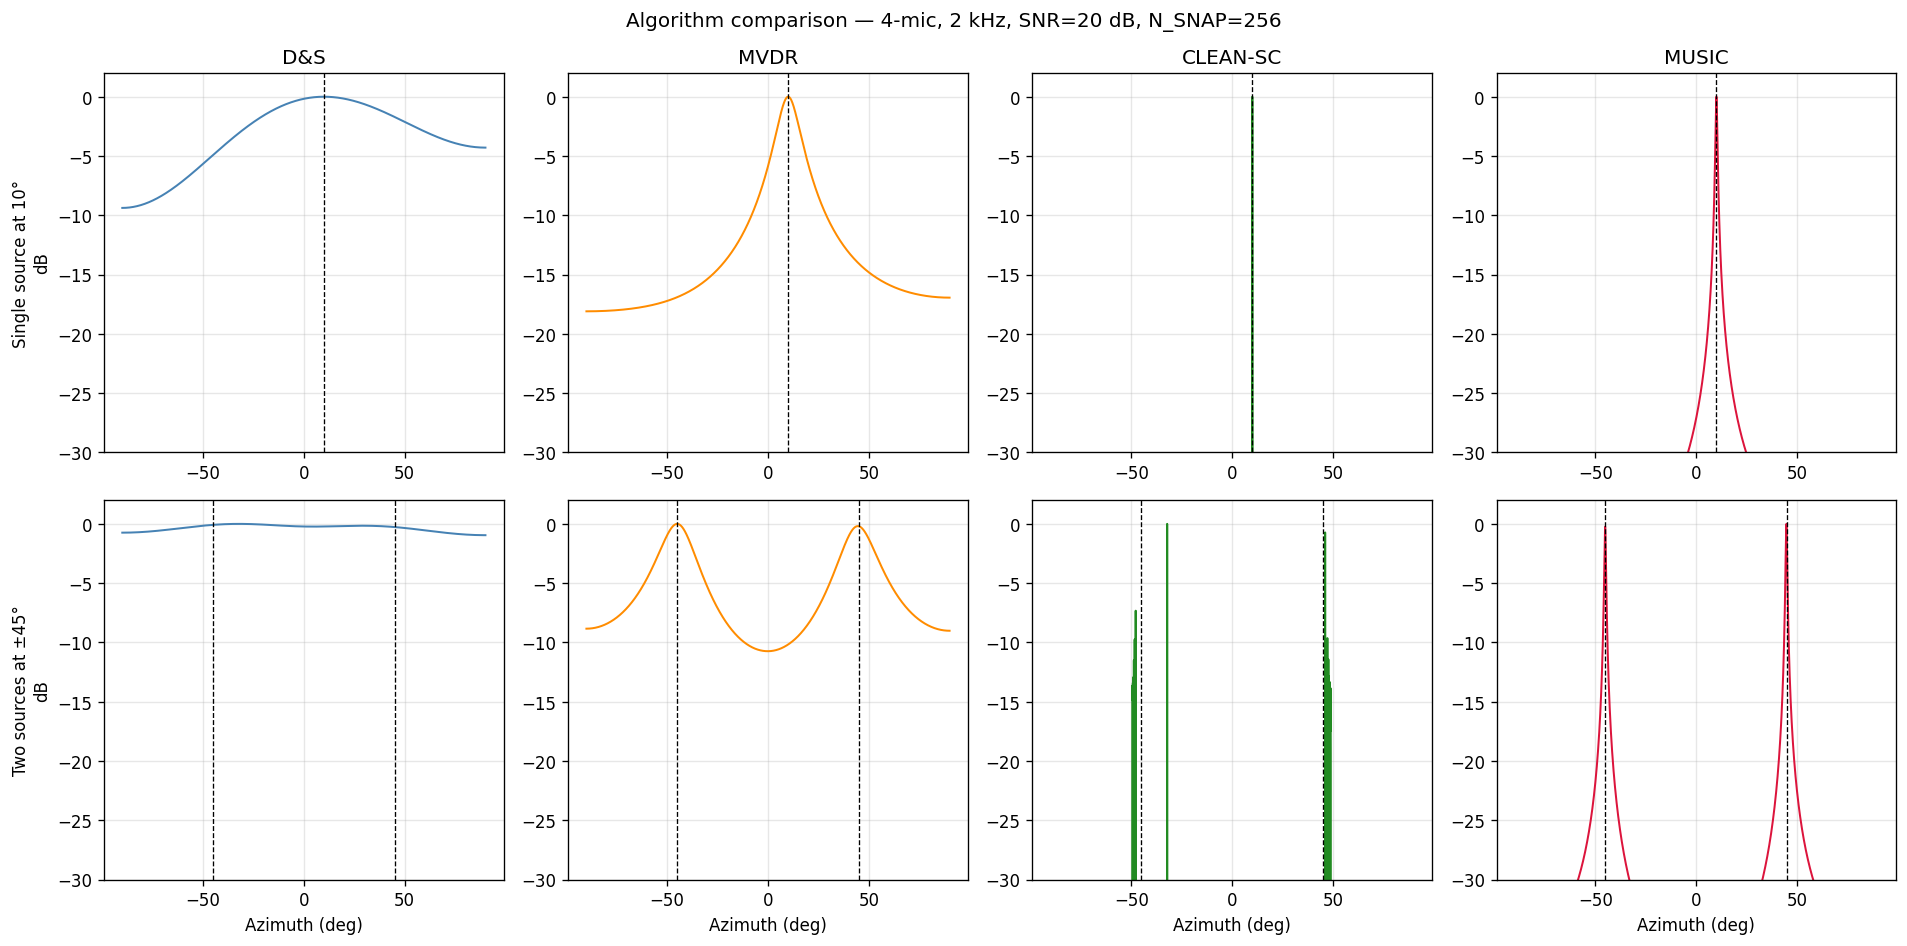

In [6]:
FREQ = 2000.0

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
scenarios = [
    ('Single source at 10°', [10.0],        {'n_sources': 1}, False),
    ('Two sources at ±45°',  [-45.0, 45.0], {'n_sources': 2}, True),
]
alg_list = [
    ('D&S',      lambda R: beamform_ds(x, y, R, FREQ, az_grid),              'steelblue'),
    ('MVDR',     lambda R: beamform_mvdr(x, y, R, FREQ, az_grid),            'darkorange'),
    ('CLEAN-SC', lambda R: clean_sc(x, y, R, FREQ, az_grid),                 'forestgreen'),
    ('MUSIC',    lambda R, ns=1: beamform_music(x, y, R, FREQ, az_grid, ns), 'crimson'),
]

for row, (title, src_az, music_kw, two_src) in enumerate(scenarios):
    R_t = make_R(x, y, src_az, FREQ, SNR_DB)
    R   = sample_csm(R_t, N_SNAP, seed=42)
    for col, (alg_name, fn, col_color) in enumerate(alg_list):
        ax = axes[row, col]
        if alg_name == 'MUSIC':
            n_s = music_kw['n_sources']
            P = beamform_music(x, y, R, FREQ, az_grid, n_sources=n_s)
        else:
            P = fn(R)
        ax.plot(az_grid, db_norm(P), color=col_color, linewidth=1.2)
        for az in src_az:
            ax.axvline(az, color='k', linestyle='--', linewidth=0.8)
        ax.set_ylim(-30, 2)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(alg_name)
        if col == 0:
            ax.set_ylabel(f'{title}\ndB')
        if row == 1:
            ax.set_xlabel('Azimuth (deg)')

plt.suptitle(f'Algorithm comparison — 4-mic, {FREQ/1000:.0f} kHz, '
             f'SNR={SNR_DB:.0f} dB, N_SNAP={N_SNAP}')
plt.tight_layout()
plt.savefig('respeaker_algo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 — DoA Accuracy vs SNR

Single source at 20°, 2 kHz, N_SNAP=256. Measure DoA error vs SNR.
With only 4 mics, spatial averaging provides ~6 dB of array gain
(vs ~20 dB for the 96-mic Phase 4 array), so the SNR floor is higher.


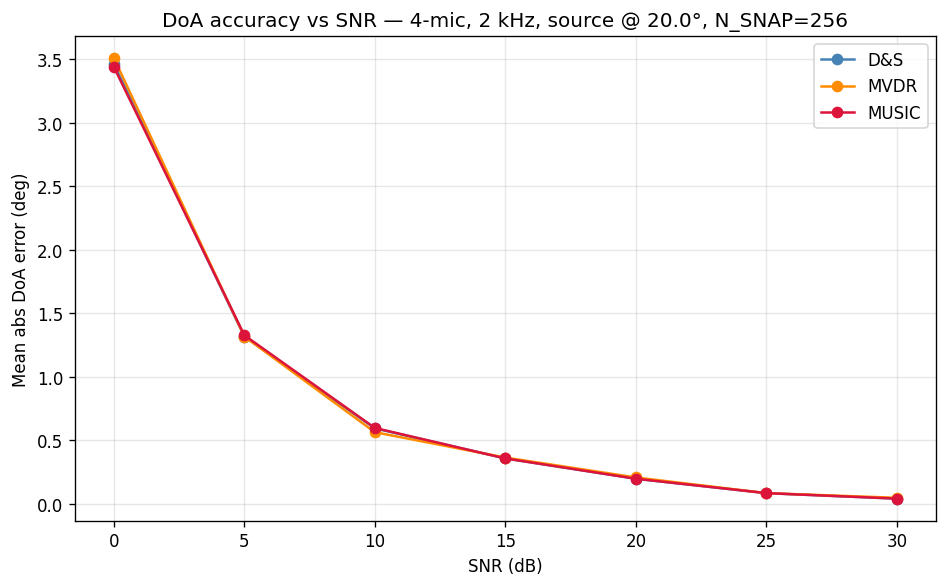

Mean DoA error (deg):
   SNR       D&S      MVDR     MUSIC
     0     3.463     3.510     3.440
     5     1.317     1.317     1.327
    10     0.593     0.563     0.597
    15     0.357     0.363     0.357
    20     0.197     0.207     0.197
    25     0.083     0.083     0.083
    30     0.040     0.047     0.040


In [7]:
SNR_VALS  = [0, 5, 10, 15, 20, 25, 30]
AZ_TRUE   = 20.0
N_TRIALS  = 30
az_scan   = np.linspace(-90, 90, 1801)

snr_results = {alg: [] for alg in ['D&S', 'MVDR', 'MUSIC']}

for snr in SNR_VALS:
    errs = {'D&S': [], 'MVDR': [], 'MUSIC': []}
    R_t  = make_R(x, y, [AZ_TRUE], FREQ, snr)
    for trial in range(N_TRIALS):
        R = sample_csm(R_t, N_SNAP, seed=trial * 100 + snr)
        for alg, fn in [
            ('D&S',   lambda R: beamform_ds(x, y, R, FREQ, az_scan)),
            ('MVDR',  lambda R: beamform_mvdr(x, y, R, FREQ, az_scan)),
            ('MUSIC', lambda R: beamform_music(x, y, R, FREQ, az_scan, n_sources=1)),
        ]:
            P = fn(R)
            errs[alg].append(abs(az_scan[np.argmax(P)] - AZ_TRUE))
    for alg in snr_results:
        snr_results[alg].append(np.mean(errs[alg]))

fig, ax = plt.subplots(figsize=(8, 5))
for alg, col in [('D&S','steelblue'),('MVDR','darkorange'),('MUSIC','crimson')]:
    ax.plot(SNR_VALS, snr_results[alg], 'o-', color=col, label=alg, linewidth=1.5)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Mean abs DoA error (deg)')
ax.set_title(f'DoA accuracy vs SNR — 4-mic, {FREQ/1000:.0f} kHz, '
             f'source @ {AZ_TRUE}°, N_SNAP={N_SNAP}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('respeaker_snr_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean DoA error (deg):')
print(f'{"SNR":>6}  {"D&S":>8}  {"MVDR":>8}  {"MUSIC":>8}')
for i, snr in enumerate(SNR_VALS):
    print(f'{snr:6d}  '
          f'{snr_results["D&S"][i]:8.3f}  '
          f'{snr_results["MVDR"][i]:8.3f}  '
          f'{snr_results["MUSIC"][i]:8.3f}')


## 6 — Snapshot Count Sweep

With N=4 mics, the 4×4 CSM is theoretically full-rank at N_SNAP ≥ 4.
CSM convergence should be fast compared to the 96-mic Phase 4 array.
Test DoA error vs N_SNAP at SNR=20 dB.


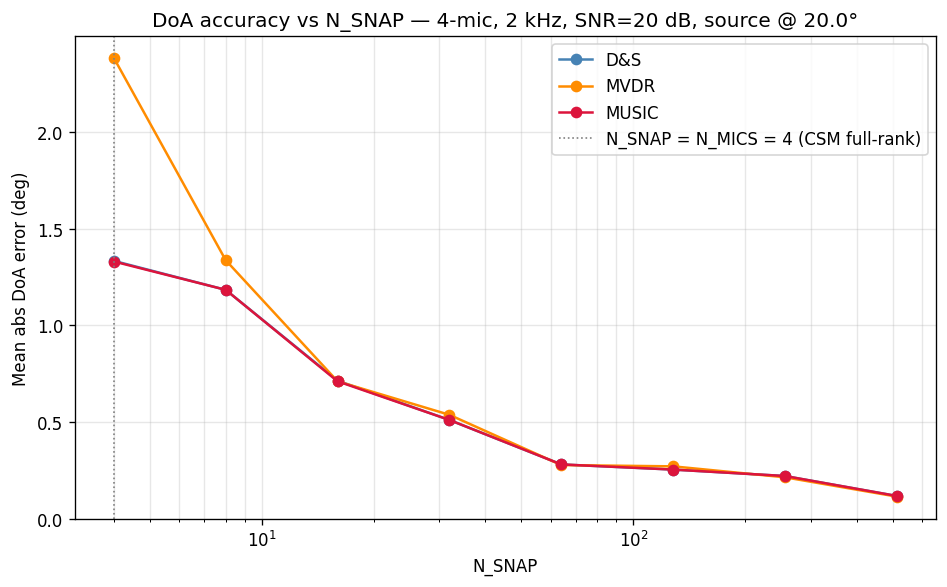

Mean DoA error (deg) vs N_SNAP:
  N_SNAP       D&S      MVDR     MUSIC
       4     1.333     2.383     1.330
       8     1.183     1.337     1.183
      16     0.713     0.710     0.710
      32     0.510     0.537     0.510
      64     0.280     0.277     0.280
     128     0.253     0.270     0.253
     256     0.220     0.213     0.220
     512     0.117     0.113     0.117


In [8]:
SNAP_VALS = [4, 8, 16, 32, 64, 128, 256, 512]
N_TRIALS2 = 30

snap_results = {alg: [] for alg in ['D&S', 'MVDR', 'MUSIC']}
R_t20 = make_R(x, y, [AZ_TRUE], FREQ, 20.0)

for n_snap in SNAP_VALS:
    errs = {'D&S': [], 'MVDR': [], 'MUSIC': []}
    for trial in range(N_TRIALS2):
        R = sample_csm(R_t20, n_snap, seed=trial * 200 + n_snap)
        for alg, fn in [
            ('D&S',   lambda R: beamform_ds(x, y, R, FREQ, az_scan)),
            ('MVDR',  lambda R: beamform_mvdr(x, y, R, FREQ, az_scan)),
            ('MUSIC', lambda R: beamform_music(x, y, R, FREQ, az_scan, n_sources=1)),
        ]:
            P = fn(R)
            errs[alg].append(abs(az_scan[np.argmax(P)] - AZ_TRUE))
    for alg in snap_results:
        snap_results[alg].append(np.mean(errs[alg]))

fig, ax = plt.subplots(figsize=(8, 5))
for alg, col in [('D&S','steelblue'),('MVDR','darkorange'),('MUSIC','crimson')]:
    ax.semilogx(SNAP_VALS, snap_results[alg], 'o-', color=col,
                label=alg, linewidth=1.5)
ax.axvline(N_MICS, color='gray', linestyle=':', linewidth=1,
           label=f'N_SNAP = N_MICS = {N_MICS} (CSM full-rank)')
ax.set_xlabel('N_SNAP')
ax.set_ylabel('Mean abs DoA error (deg)')
ax.set_title(f'DoA accuracy vs N_SNAP — 4-mic, {FREQ/1000:.0f} kHz, '
             f'SNR=20 dB, source @ {AZ_TRUE}°')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('respeaker_snap_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean DoA error (deg) vs N_SNAP:')
print(f'{"N_SNAP":>8}  {"D&S":>8}  {"MVDR":>8}  {"MUSIC":>8}')
for i, n_snap in enumerate(SNAP_VALS):
    print(f'{n_snap:8d}  '
          f'{snap_results["D&S"][i]:8.3f}  '
          f'{snap_results["MVDR"][i]:8.3f}  '
          f'{snap_results["MUSIC"][i]:8.3f}')


## 7 — Phase 2 vs Phase 4 Expected Performance

Summary table comparing what to expect from the 4-mic smoke-test array vs the
96-mic Underbrink target.


In [9]:
# Phase 4 reference values from Phase 1 notebooks
p4_hpbw = {500: '>180°', 1000: '82°', 2000: '38°', 4000: '19°', 8000: '9°'}

rows = []
for freq, hpbw in zip(FREQS, hpbw_arr):
    p4 = p4_hpbw.get(freq, '—')
    p2 = f'{hpbw:.0f}°' if not np.isnan(hpbw) else '>180° (omni)'
    rows.append({'Freq (Hz)': freq, 'Phase 2 HPBW (4-mic)': p2,
                 'Phase 4 HPBW (96-mic)': p4})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()

summary = [
    ('Mic count',          '4',              '96'),
    ('Aperture',           '90 mm',          '300 mm'),
    ('Min spacing',        '63.6 mm',        '12.9 mm'),
    ('Spatial Nyquist',    f'{f_nyquist:.0f} Hz', '~13 kHz'),
    ('Useful freq range',  '≤ ~2.5 kHz',     '200 Hz – 8 kHz'),
    ('Array gain',         '~6 dB',          '~20 dB'),
    ('SNR floor (DoA)',    '~15 dB',          '~10 dB'),
    ('Calibration need',   'High (4-ch avg)',  'Low (96-ch avg suppresses errors)'),
    ('MUSIC benefit',      'Limited (N=4)',   'Strong (N=96)'),
    ('Purpose',            'Pipeline smoke test', 'Production acoustic camera'),
]
df2 = pd.DataFrame(summary, columns=['Parameter', 'Phase 2 (ReSpeaker)', 'Phase 4 (target)'])
print(df2.to_string(index=False))


 Freq (Hz) Phase 2 HPBW (4-mic) Phase 4 HPBW (96-mic)
       500                 180°                 >180°
      1000                 180°                   82°
      1500                 135°                     —
      2000                  88°                   38°
      2500                  67°                     —

        Parameter Phase 2 (ReSpeaker)                  Phase 4 (target)
        Mic count                   4                                96
         Aperture               90 mm                            300 mm
      Min spacing             63.6 mm                           12.9 mm
  Spatial Nyquist             2695 Hz                           ~13 kHz
Useful freq range          ≤ ~2.5 kHz                    200 Hz – 8 kHz
       Array gain               ~6 dB                            ~20 dB
  SNR floor (DoA)              ~15 dB                            ~10 dB
 Calibration need     High (4-ch avg) Low (96-ch avg suppresses errors)
    MUSIC benefit       Lim